In [50]:
import pandas as pd

# استيراد داتا car_purchasing
df = pd.read_csv(r'D:\AI-and-Machine_Learning_Diploma\Deep_Learning\Session_4\Data\car_purchasing.csv.xls', encoding='ISO-8859-1')

In [51]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    str    
 1   customer e-mail      500 non-null    str    
 2   country              500 non-null    str    
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 35.3 KB


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [53]:
import random
import os
def set_deterministic_state(seed: int = 42):
    # 1. Base Python randomness
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy randomness
    np.random.seed(seed)

    # 3. PyTorch CPU and CUDA randomness
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # 4. Enforce deterministic algorithms in CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [54]:
X = df.iloc[:, 3:-1]
y = df.iloc[:, -1]

In [55]:
'''defision model the strongest deep learning model'''

xsc = StandardScaler()
X = xsc.fit_transform(X)
ysc = StandardScaler()
y = ysc.fit_transform(y.values.reshape(-1, 1))

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [57]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)


In [58]:

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [59]:
class car_purchasing_model (nn.Module):
    def __init__(self):
        super(car_purchasing_model, self).__init__()
        self.fc1 = nn.Linear(5,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)
        self.relu = nn.ReLU()

    def forward(self,x):
        a1 = self.relu(self.fc1(x))
        a2 = self.relu(self.fc2(a1))
        yhat = self.fc3(a2)
        return yhat
set_deterministic_state(42)
model = car_purchasing_model()
print(model)

car_purchasing_model(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


In [60]:
for name, param in model.named_parameters():
    print(name)

fc1.weight
fc1.bias
fc2.weight
fc2.bias
fc3.weight
fc3.bias


In [61]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

epochs = 100
for epoch in range(epochs):
    for xb ,yb in train_loader :
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch: {epoch+1}/{epochs} | Loss: {loss.item():.4f}")


Epoch: 10/100 | Loss: 0.0026
Epoch: 20/100 | Loss: 0.0009
Epoch: 30/100 | Loss: 0.0007
Epoch: 40/100 | Loss: 0.0003
Epoch: 50/100 | Loss: 0.0003
Epoch: 60/100 | Loss: 0.0002
Epoch: 70/100 | Loss: 0.0001
Epoch: 80/100 | Loss: 0.0002
Epoch: 90/100 | Loss: 0.0001
Epoch: 100/100 | Loss: 0.0001


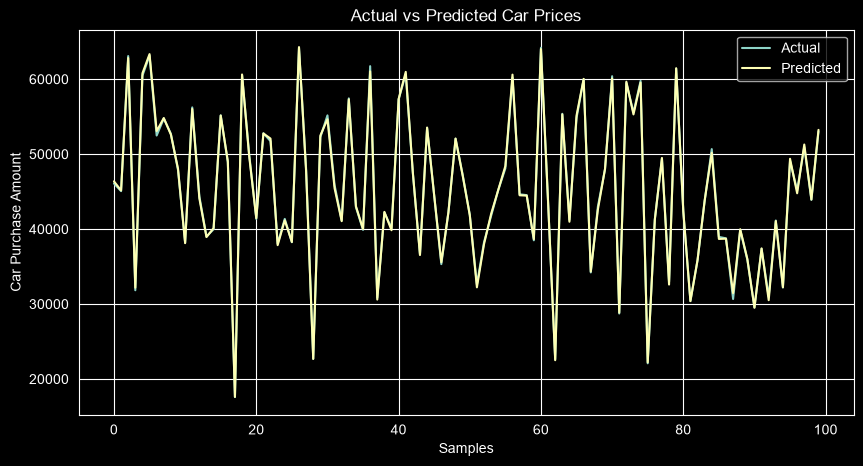

In [63]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    true = y_test_tensor.numpy()
    predictions = ysc.inverse_transform(predictions)
    true = ysc.inverse_transform(true)

import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10,5))
plt.plot(true, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Samples")
plt.ylabel("Car Purchase Amount")
plt.show()

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(true, predictions)
mae = mean_absolute_error(true, predictions)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Mean Squared Error: 57464.88
Mean Absolute Error: 184.02


In [65]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(true, predictions)

print(f"MAPE: {mape * 100:.2f}%")

MAPE: 0.42%
